In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Cadetx '))

['ev_charging_dataset.xlsx', 'daily_demand.csv', 'weekly_demand_pattern.csv', 'hourly_demand_pattern.csv']


In [ ]:
all_sheets = pd.read_excel('/content/drive/MyDrive/Cadetx /ev_charging_dataset.xlsx', sheet_name=None)
print(all_sheets.keys())

dict_keys(['stations', 'chargers', 'sessions'])


In [ ]:
stations_df = all_sheets['stations']
chargers_df = all_sheets['chargers']
sessions_df = all_sheets['sessions']

print("STATIONS:", stations_df.shape)
print(stations_df.head())

print("\nCHARGERS:", chargers_df.shape)
print(chargers_df.head())

print("\nSESSIONS:", sessions_df.shape)
print(sessions_df.head())

STATIONS: (33, 5)
  station_id     station_name      region  activation_year  n_chargers
0    STN_001  EV FastCharge 1  North West             2022           4
1    STN_002  EV FastCharge 2      London             2022           5
2    STN_003  EV FastCharge 3    Midlands             2022           5
3    STN_004  EV FastCharge 4  North West             2022           8
4    STN_005  EV FastCharge 5  North West             2022           8

CHARGERS: (199, 5)
      charger_id station_id charger_type  max_power_kW installation_date
0  STN_001_CH_01    STN_001      DC_50kW            50        2022-06-07
1  STN_001_CH_02    STN_001     DC_150kW           150        2022-12-22
2  STN_001_CH_03    STN_001     DC_150kW           150        2022-10-21
3  STN_001_CH_04    STN_001      DC_50kW            50        2022-12-08
4  STN_002_CH_01    STN_002      DC_50kW            50        2022-07-09

SESSIONS: (294024, 15)
   session_id station_id     charger_id charger_type     start_timestamp  

In [ ]:
print(sessions_df.dtypes)
print(sessions_df.info())

session_id                          object
station_id                          object
charger_id                          object
charger_type                        object
start_timestamp             datetime64[ns]
end_timestamp               datetime64[ns]
session_duration_minutes             int64
energy_kwh                         float64
price_per_kwh                      float64
total_cost                         float64
payment_method                      object
user_type                           object
customer_id                         object
station_region                      object
year                                 int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294024 entries, 0 to 294023
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   session_id                294024 non-null  object        
 1   station_id                294024 non

In [ ]:
print(sessions_df.isnull().sum())

session_id                  0
station_id                  0
charger_id                  0
charger_type                0
start_timestamp             0
end_timestamp               0
session_duration_minutes    0
energy_kwh                  0
price_per_kwh               0
total_cost                  0
payment_method              0
user_type                   0
customer_id                 0
station_region              0
year                        0
dtype: int64


In [ ]:
print(sessions_df.duplicated().sum())

0


In [ ]:
print(sessions_df['start_timestamp'].min(), "to", sessions_df['start_timestamp'].max())
print(sessions_df.describe())

2022-01-01 01:30:00 to 2024-12-31 23:50:00
                     start_timestamp                  end_timestamp  \
count                         294024                         294024   
mean   2023-12-06 21:39:31.539058432  2023-12-06 22:14:37.224716544   
min              2022-01-01 01:30:00            2022-01-01 01:54:00   
25%              2023-05-20 05:25:00            2023-05-20 06:00:15   
50%              2024-02-13 20:25:00            2024-02-13 21:04:00   
75%              2024-07-24 06:42:30            2024-07-24 07:06:45   
max              2024-12-31 23:50:00            2025-01-01 00:42:00   
std                              NaN                            NaN   

       session_duration_minutes     energy_kwh  price_per_kwh     total_cost  \
count             294024.000000  294024.000000  294024.000000  294024.000000   
mean                  35.094761      46.964689       0.592319      27.790589   
min                   15.000000      21.700000       0.450000      11.450000 

In [ ]:
sessions_df['date'] = sessions_df['start_timestamp'].dt.date

daily_demand = sessions_df.groupby('date').size().reset_index(name='session_count')
print(daily_demand.head())
print(daily_demand.shape)

         date  session_count
0  2022-01-01             94
1  2022-01-02             80
2  2022-01-03            123
3  2022-01-04            116
4  2022-01-05            126
(1096, 2)


In [ ]:
sessions_df['hour'] = sessions_df['start_timestamp'].dt.hour

hourly_demand = sessions_df.groupby('hour').size().reset_index(name='session_count')
print(hourly_demand)

    hour  session_count
0      0           2754
1      1           2677
2      2           2719
3      3           2633
4      4           2705
5      5           5360
6      6           7985
7      7          10648
8      8          15967
9      9          21370
10    10          24214
11    11          24048
12    12          23945
13    13          24123
14    14          24120
15    15          21251
16    16          18750
17    17          15992
18    18          13480
19    19          10628
20    20           7959
21    21           5353
22    22           2677
23    23           2666


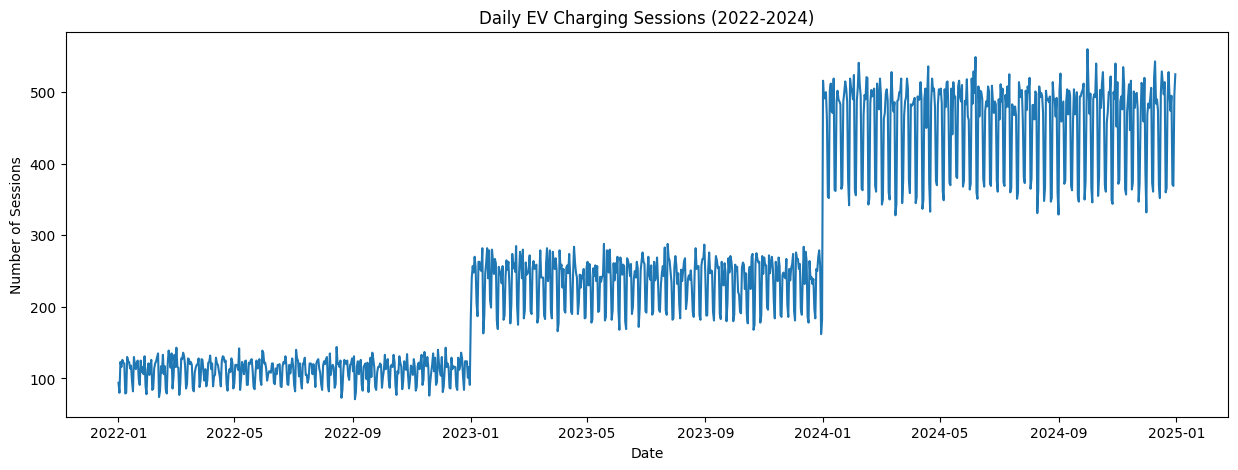

In [ ]:
import matplotlib.pyplot as plt

daily_demand['date'] = pd.to_datetime(daily_demand['date'])

plt.figure(figsize=(15, 5))
plt.plot(daily_demand['date'], daily_demand['session_count'])
plt.title('Daily EV Charging Sessions (2022-2024)')
plt.xlabel('Date')
plt.ylabel('Number of Sessions')
plt.show()

In [ ]:
print(stations_df['activation_year'].value_counts().sort_index())

activation_year
2022     8
2023     9
2024    16
Name: count, dtype: int64


In [ ]:
sessions_df['day_of_week'] = sessions_df['start_timestamp'].dt.day_name()
weekly_demand = sessions_df.groupby('day_of_week').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).reset_index(name='session_count')
print(weekly_demand)

  day_of_week  session_count
0      Monday          45733
1     Tuesday          45922
2   Wednesday          45106
3    Thursday          45070
4      Friday          45529
5    Saturday          33335
6      Sunday          33329


In [ ]:
daily_demand.to_csv('/content/drive/MyDrive/Cadetx /daily_demand.csv', index=False)
hourly_demand.to_csv('/content/drive/MyDrive/Cadetx /hourly_demand_pattern.csv', index=False)
weekly_demand.to_csv('/content/drive/MyDrive/Cadetx /weekly_demand_pattern.csv', index=False)

print("All files saved successfully!")

All files saved successfully!


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

prophet_df = daily_demand.rename(columns={'date': 'ds', 'session_count': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

print(prophet_df.head())

          ds    y
0 2022-01-01   94
1 2022-01-02   80
2 2022-01-03  123
3 2022-01-04  116
4 2022-01-05  126


In [ ]:
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=365)  # extends 365 days beyond your last date
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

             ds        yhat  yhat_lower  yhat_upper
1456 2025-12-27  598.271589  540.736644  649.048608
1457 2025-12-28  606.354574  551.706681  662.156527
1458 2025-12-29  693.816341  641.467457  748.329606
1459 2025-12-30  703.717907  652.116234  759.204227
1460 2025-12-31  710.964894  658.335675  766.677141


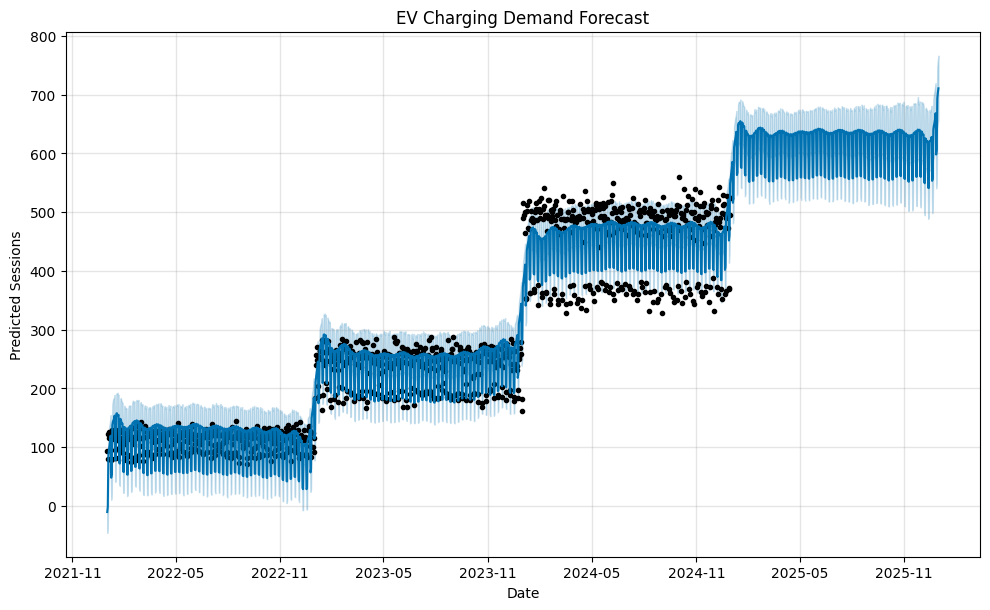

In [ ]:
fig = model.plot(forecast)
plt.title('EV Charging Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sessions')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Merge actual data with forecasted data on matching dates
comparison = prophet_df.merge(forecast[['ds', 'yhat']], on='ds')

print(comparison.head())
print(comparison.shape)

          ds    y        yhat
0 2022-01-01   94  -10.404087
1 2022-01-02   80   -1.646309
2 2022-01-03  123   85.998478
3 2022-01-04  116   95.585664
4 2022-01-05  126  102.024872
(1096, 3)


In [ ]:
mape = mean_absolute_percentage_error(comparison['y'], comparison['yhat']) * 100
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

MAPE: 11.19%
RMSE: 27.57
